<a href="https://colab.research.google.com/github/julestek/nlp-ticket-classification/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import userdata

!mkdir -p ~/.kaggle
token = userdata.get('KAGGLE_TOKEN')
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(token)
!chmod 600 ~/.kaggle/access_token

!pip install -q kaggle

!kaggle datasets download -d adisongoh/it-service-ticket-classification-dataset -p data/raw --unzip

Dataset URL: https://www.kaggle.com/datasets/adisongoh/it-service-ticket-classification-dataset
License(s): CC0-1.0
100% 3.45M/3.45M [00:00<00:00, 178MB/s]



In [ ]:
import os
print(os.listdir("data/raw"))

['all_tickets_processed_improved_v3.csv']


In [ ]:
import pandas as pd

df = pd.read_csv("data/raw/all_tickets_processed_improved_v3.csv")  # remplace par le vrai nom vu ci-dessus

print(f"Shape: {df.shape}")
df.head()

Shape: (47837, 2)


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

Topic_group
Hardware                 28.465414
HR Support               22.817066
Access                   14.894329
Miscellaneous            14.758451
Storage                   5.805130
Purchase                  5.150825
Internal Project          4.429626
Administrative rights     3.679160
Name: proportion, dtype: float64


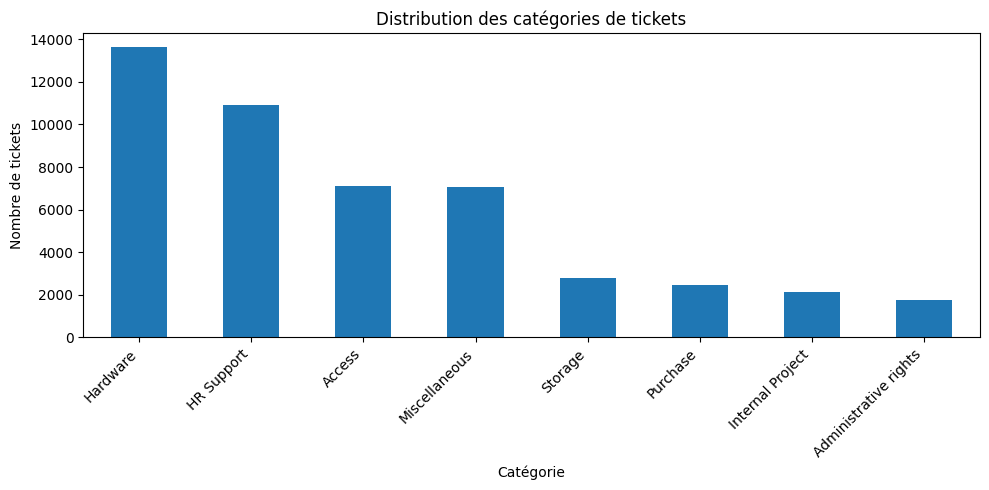

In [ ]:
import matplotlib.pyplot as plt

# Comptage brut
print(df['Topic_group'].value_counts())
print()
# En pourcentage, plus parlant pour évaluer le déséquilibre
print(df['Topic_group'].value_counts(normalize=True) * 100)

# Visualisation
plt.figure(figsize=(10, 5))
df['Topic_group'].value_counts().plot(kind='bar')
plt.title("Distribution des catégories de tickets")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de tickets")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()